## 🍱 Mixed turbine power

**Concepts:** [Turbines of unequal output](../reference/input_formats.md#turbines-of-unequal-output) · **Advanced API:** [Mixed turbine power](lo16_mixed_power.ipynb)

`WindFarmNetwork` accepts one nominal power per turbine in `turbine_powers`, in coordinate order. Set `power_unit='MW'` to express turbine ratings and cable capacities in MW; coordinate inputs do not infer a power unit.

With `power_unit=None` (the default), powers and cable capacities are integer inflow. Without explicit `turbine_powers`, every turbine contributes **unitary inflow** and cable capacities count turbines. With a physical unit, equal declared powers also use one inflow per turbine, worth the common power rating. Unequal powers are declared on the location and quantized for each solve.

In [1]:
from fractions import Fraction

import numpy as np
from tabulate import tabulate

from optiwindnet.api import MILPRouter, WindFarmNetwork
from optiwindnet.importer import load_repository
from optiwindnet.loads import _inflow_of
from optiwindnet.svg import svgplot

### A six-turbine site

Three turbines produce 5 MW and three produce 6.35 MW, for a total of 34.05 MW. The two cable types carry 16 MW and 20 MW; their illustrative costs are per metre. Coordinates are in metres.

Use a branched `MILPRouter` with the OR-Tools CP-SAT backend. `warmup=False` makes this small example a direct MILP solve; larger cases can benefit from the default heuristic warm start. The time limit and MIP gap control the solve, independently of the power quantization tolerance.

In [2]:
site = {
    'turbinesC': 1000
    * np.array(
        [
            [0.0, 0.0],
            [1.0, 0.4],
            [2.0, 0.0],
            [0.3, 1.2],
            [1.3, 1.6],
            [2.4, 1.1],
        ]
    ),
    'substationsC': 1000 * np.array([[1.2, -1.0]]),
    'borderC': 1000
    * np.array(
        [
            [-0.5, -1.5],
            [3.0, -1.5],
            [3.0, 2.1],
            [-0.5, 2.1],
        ]
    ),
}
powers_MW = [5.0, 6.35] * 3
cables_MW = [(16.0, 1.0), (20.0, 1.3)]

In [3]:
def make_router(power_rtol=0.01):
    return MILPRouter(
        'ortools.cp_sat',
        power_rtol=power_rtol,
        time_limit=10,
        mip_gap=0.01,
        warmup=False,
        model_options={'topology': 'branched', 'feeder_limit': 'unlimited'},
    )

In [4]:
mixed = WindFarmNetwork(
    **site,
    name='Mixed ratings: 5 and 6.35 MW',
    cables=cables_MW,
    power_unit='MW',
    turbine_powers=powers_MW,
    router=make_router(),
)
mixed.optimize()

TerseLinks(scope='topology', topology='branched', T=6, R=1, links=6)

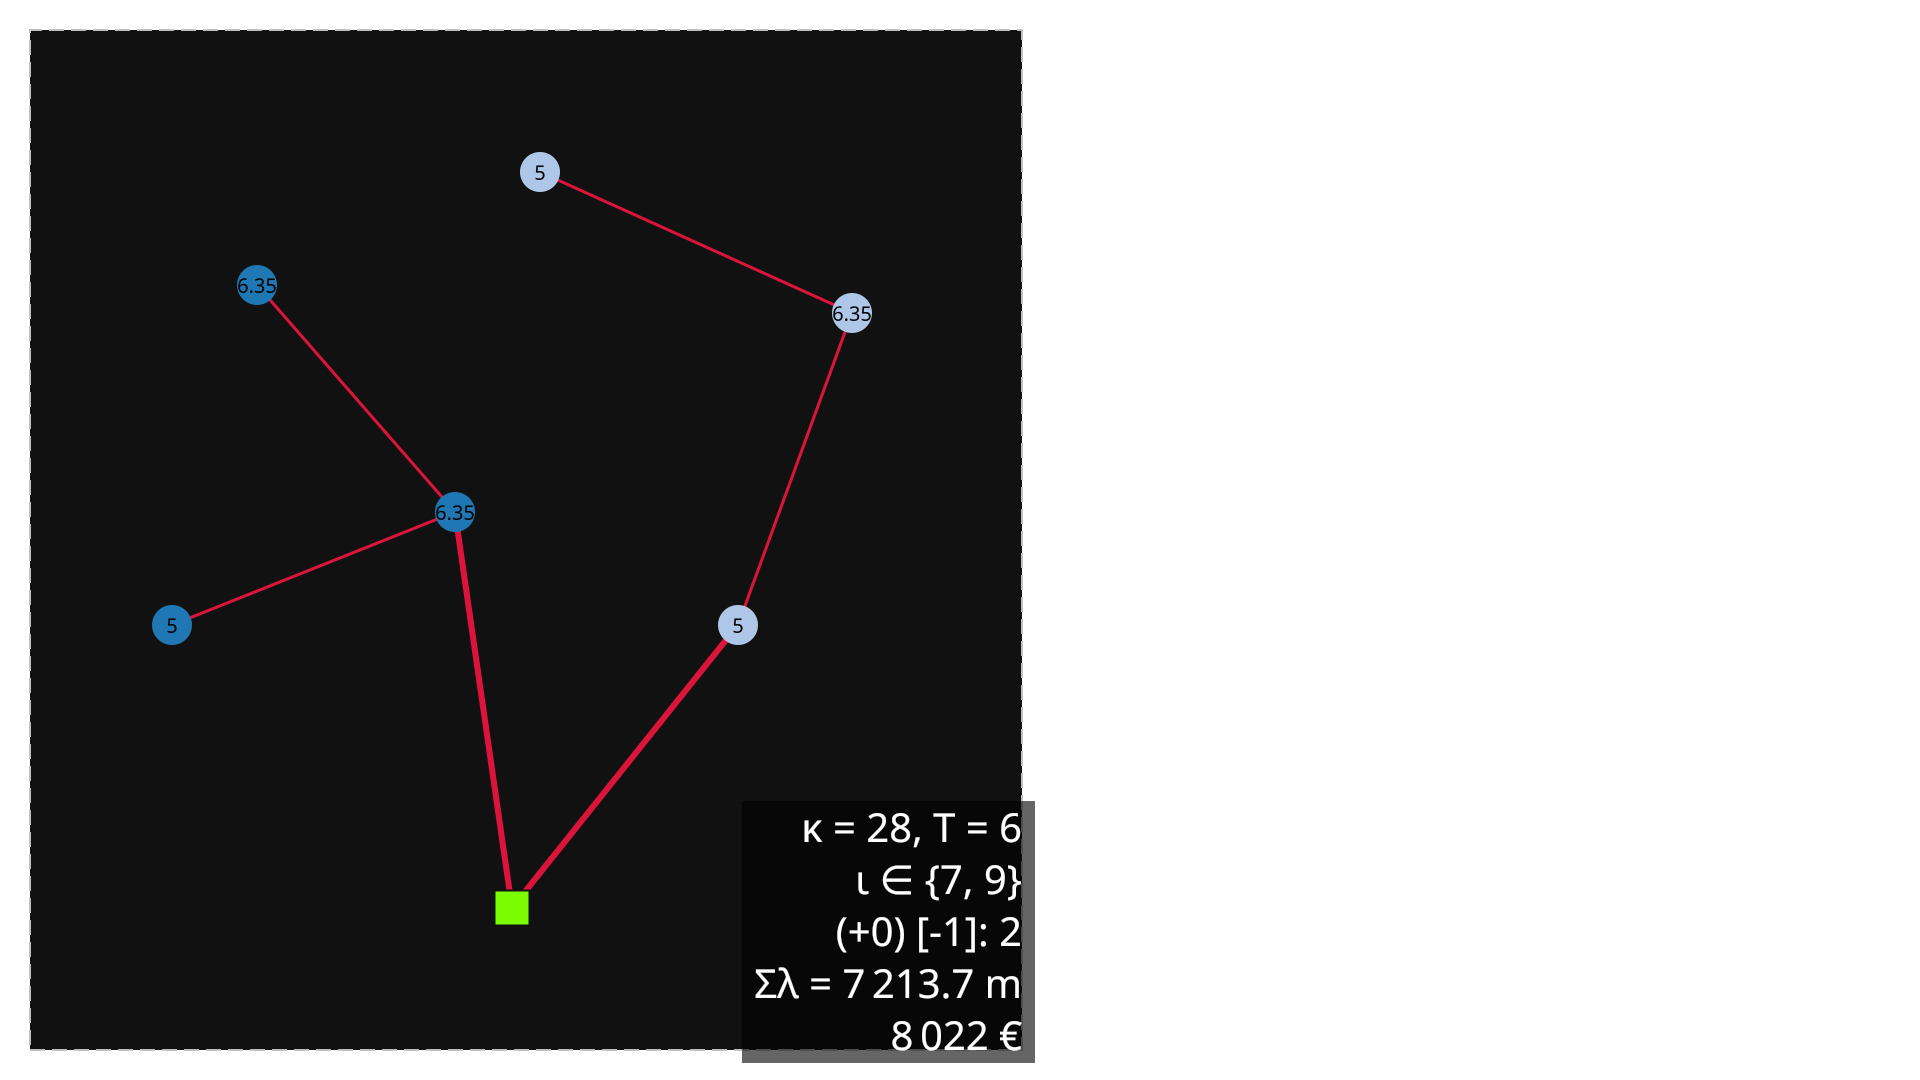

In [5]:
svgplot(mixed.G, node_tag='power')

### Declared power and integer inflow

Solvers work with positive integer inflow. `mixed.turbine_powers` retains the declared values as `Fraction` objects, and `mixed.cables` retains nominal capacities in MW as fractions. Float inputs are rationalized; pass `Fraction` values when an exact ratio is part of the input specification.

The router's default `power_rtol=0.01` permits at most 1% relative error **per turbine** between declared power and `inflow * power_per_inflow`. It is not a decimal-place setting. Each solve chooses a conversion that also preserves which turbine groups fit the largest nominal cable capacity. Smaller cable types are assigned afterwards using declared downstream power.

The conversion belongs to the solution: read `power_per_inflow` and the largest integer `capacity` from `mixed.G.graph`. The location and available-links graphs retain the nominal declaration, without quantized inflows.

In [6]:
mixed.turbine_powers

[Fraction(5, 1),
 Fraction(127, 20),
 Fraction(5, 1),
 Fraction(127, 20),
 Fraction(5, 1),
 Fraction(127, 20)]

In [7]:
mixed.G.graph['power_per_inflow']

Fraction(17, 24)

In [8]:
mixed.cables

[(Fraction(16, 1), 1.0), (Fraction(20, 1), 1.3)]

In [9]:
mixed.G.graph['capacity']

28

In [10]:
power_per_inflow = mixed.G.graph['power_per_inflow']
headers = ('nominal MW', 'inflow', 'represented MW', 'relative error (%)')
rows = []
for t, power in enumerate(mixed._L.graph['powers_set']):
    inflow = _inflow_of(power, power_per_inflow)
    represented = inflow * power_per_inflow
    error = abs(represented - power) / power
    assert error <= Fraction(1, 100)
    rows.append((power, inflow, represented, 100 * error))
tabulate(rows, headers=headers, tablefmt='html')

nominal MW,inflow,represented MW,relative error (%)
5,7,4.95833,0.833333
6.35,9,6.375,0.393701


### Exact power versus a 1% tolerance

With zero tolerance, 5 MW and 6.35 MW become 100 and 127 inflow units, each representing 1/20 MW. The default tolerance and the largest capacity of 20 MW instead allow inflows of 7 and 9, each unit valued at 17/24 MW. Smaller integer injections can make the MILP easier to solve.

Both conversions admit the same turbine groups for the 20 MW routing budget. For example, four 5 MW turbines fit, but three 5 MW turbines plus one 6.35 MW turbine do not. The checks below concern possible combinations of ratings, independently of how many turbines of each rating this site contains.

A looser tolerance need not change the conversion: the capacity threshold can require a finer unit. The packing guarantee concerns the largest cable used for routing, rather than a simultaneous conversion of every cable type. Cable assignment compares each edge's nominal load directly with the nominal cable specifications.

In [11]:
exact = WindFarmNetwork(
    **site,
    name='Mixed ratings: exact conversion',
    cables=cables_MW,
    power_unit='MW',
    turbine_powers=powers_MW,
    router=make_router(power_rtol=0),
)
exact.optimize()

TerseLinks(scope='topology', topology='branched', T=6, R=1, links=6)

In [12]:
assert all(
    exact.G.nodes[t]['inflow'] * exact.G.graph['power_per_inflow'] == power
    for t, power in enumerate(exact.turbine_powers)
)
rows = []
for label, network in [('Exact', exact), ('1% tolerance', mixed)]:
    inflow = [network.G.nodes[t]['inflow'] for t in range(6)]
    capacity = network.G.graph['capacity']
    assert 4 * inflow[0] <= capacity
    assert 3 * inflow[0] + inflow[1] > capacity
    rows.append(
        (
            label,
            str(network.G.graph['power_per_inflow']),
            inflow,
            capacity,
            [float(cable_capacity) for cable_capacity, _ in network.cables],
        )
    )
tabulate(
    rows,
    headers=[
        'conversion',
        'MW per inflow',
        'inflow',
        'capacity (inflow)',
        'cable capacities (MW)',
    ],
    tablefmt='html',
)

conversion,MW per inflow,inflow,capacity (inflow),cable capacities (MW)
Exact,1/20,"[100, 127, 100, 127, 100, 127]",400,"[16.0, 20.0]"
1% tolerance,17/24,"[7, 9, 7, 9, 7, 9]",28,"[16.0, 20.0]"


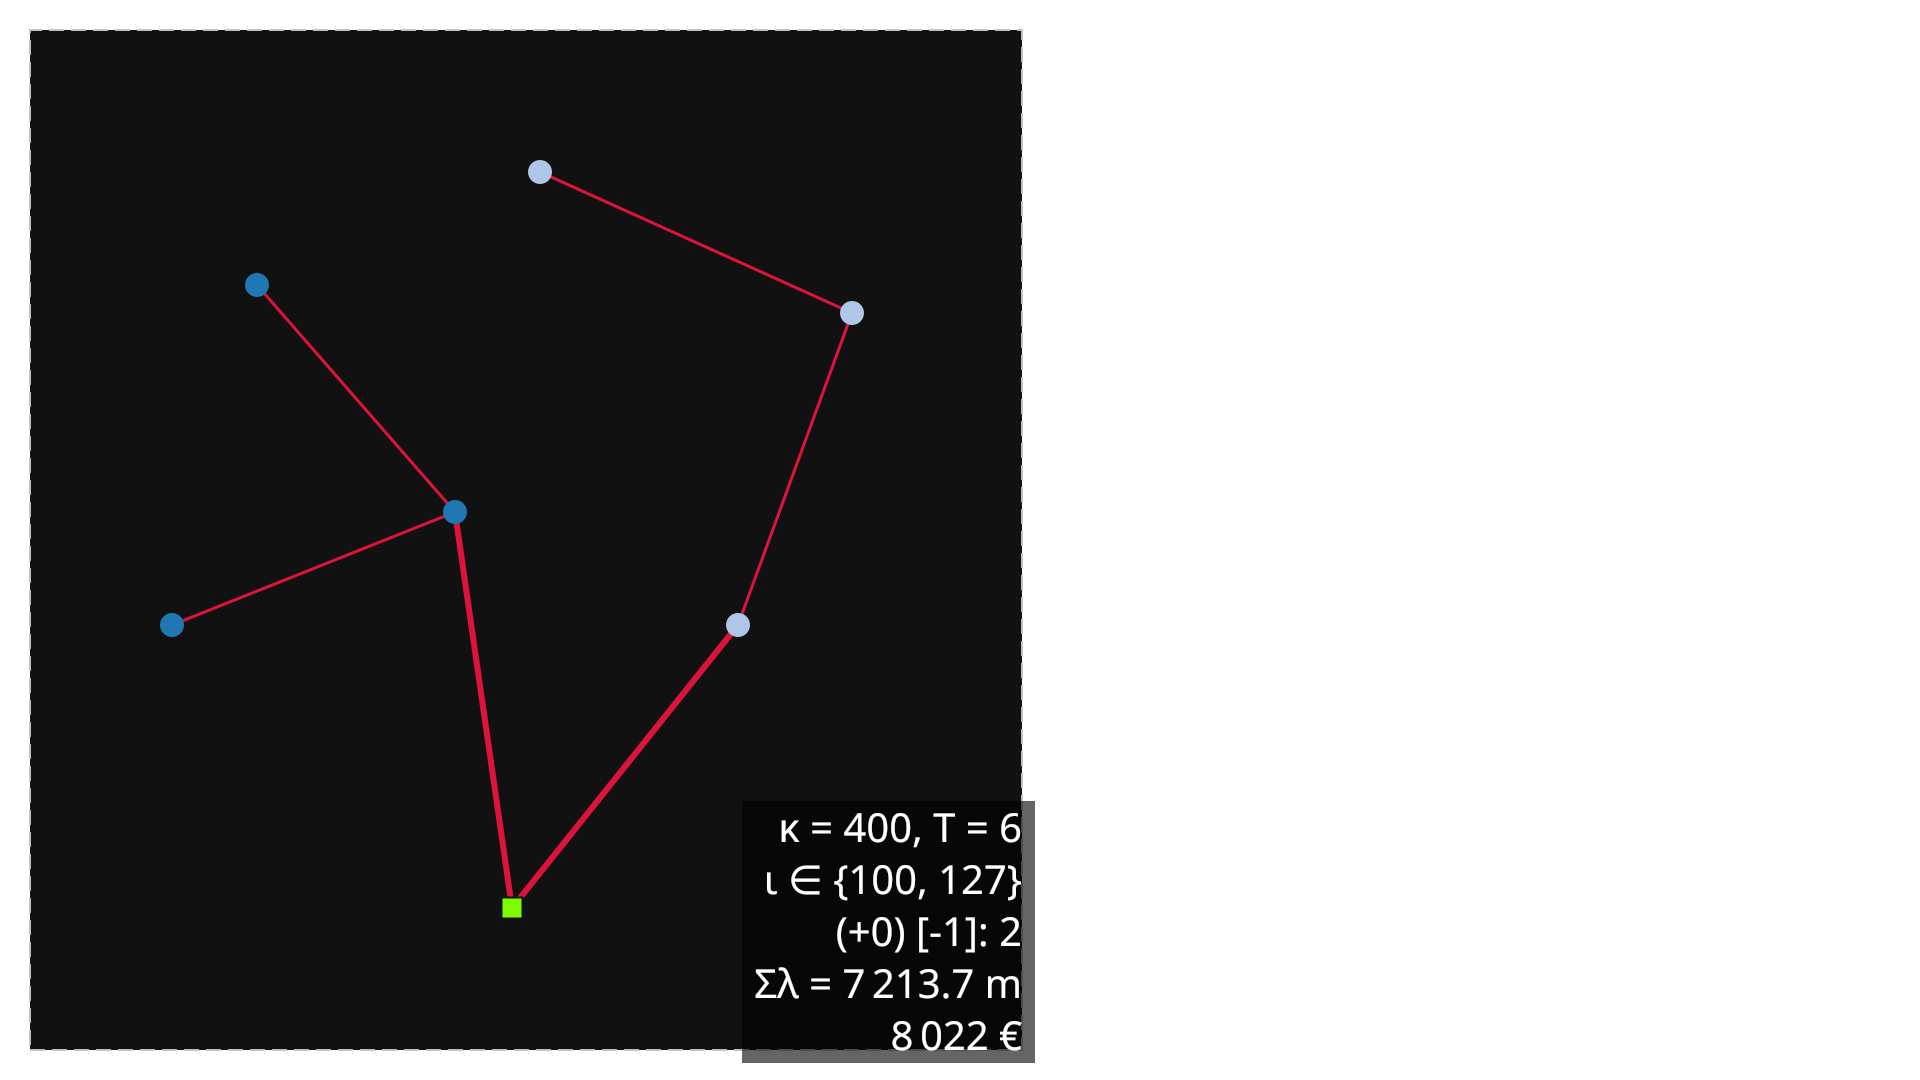

In [13]:
exact

### Compare with uniform ratings

For a meaningful comparison in MW, declare 5 MW for **every** turbine and keep the same cables and geometry. This reduces total generation to 30 MW; it is a different design case, not an alternative encoding of the mixed site. Every turbine then contributes one inflow worth 5 MW.

Omitting the declaration entirely on this coordinate-only site instead retains the historical unit-inflow interpretation: a capacity of 3 means three turbines, with no physical MW rating supplied.

In [14]:
uniform = WindFarmNetwork(
    **site,
    name='Uniform ratings: 5 MW',
    cables=cables_MW,
    power_unit='MW',
    turbine_powers=[5.0] * 6,
    router=make_router(),
)
uniform.optimize()

TerseLinks(scope='topology', topology='branched', T=6, R=1, links=6)

In [15]:
{
    'MW_per_inflow': uniform.G.graph['power_per_inflow'],
    'cable_capacities_MW': uniform.cables,
}

{'MW_per_inflow': Fraction(5, 1),
 'cable_capacities_MW': [(Fraction(16, 1), 1.0), (Fraction(20, 1), 1.3)]}

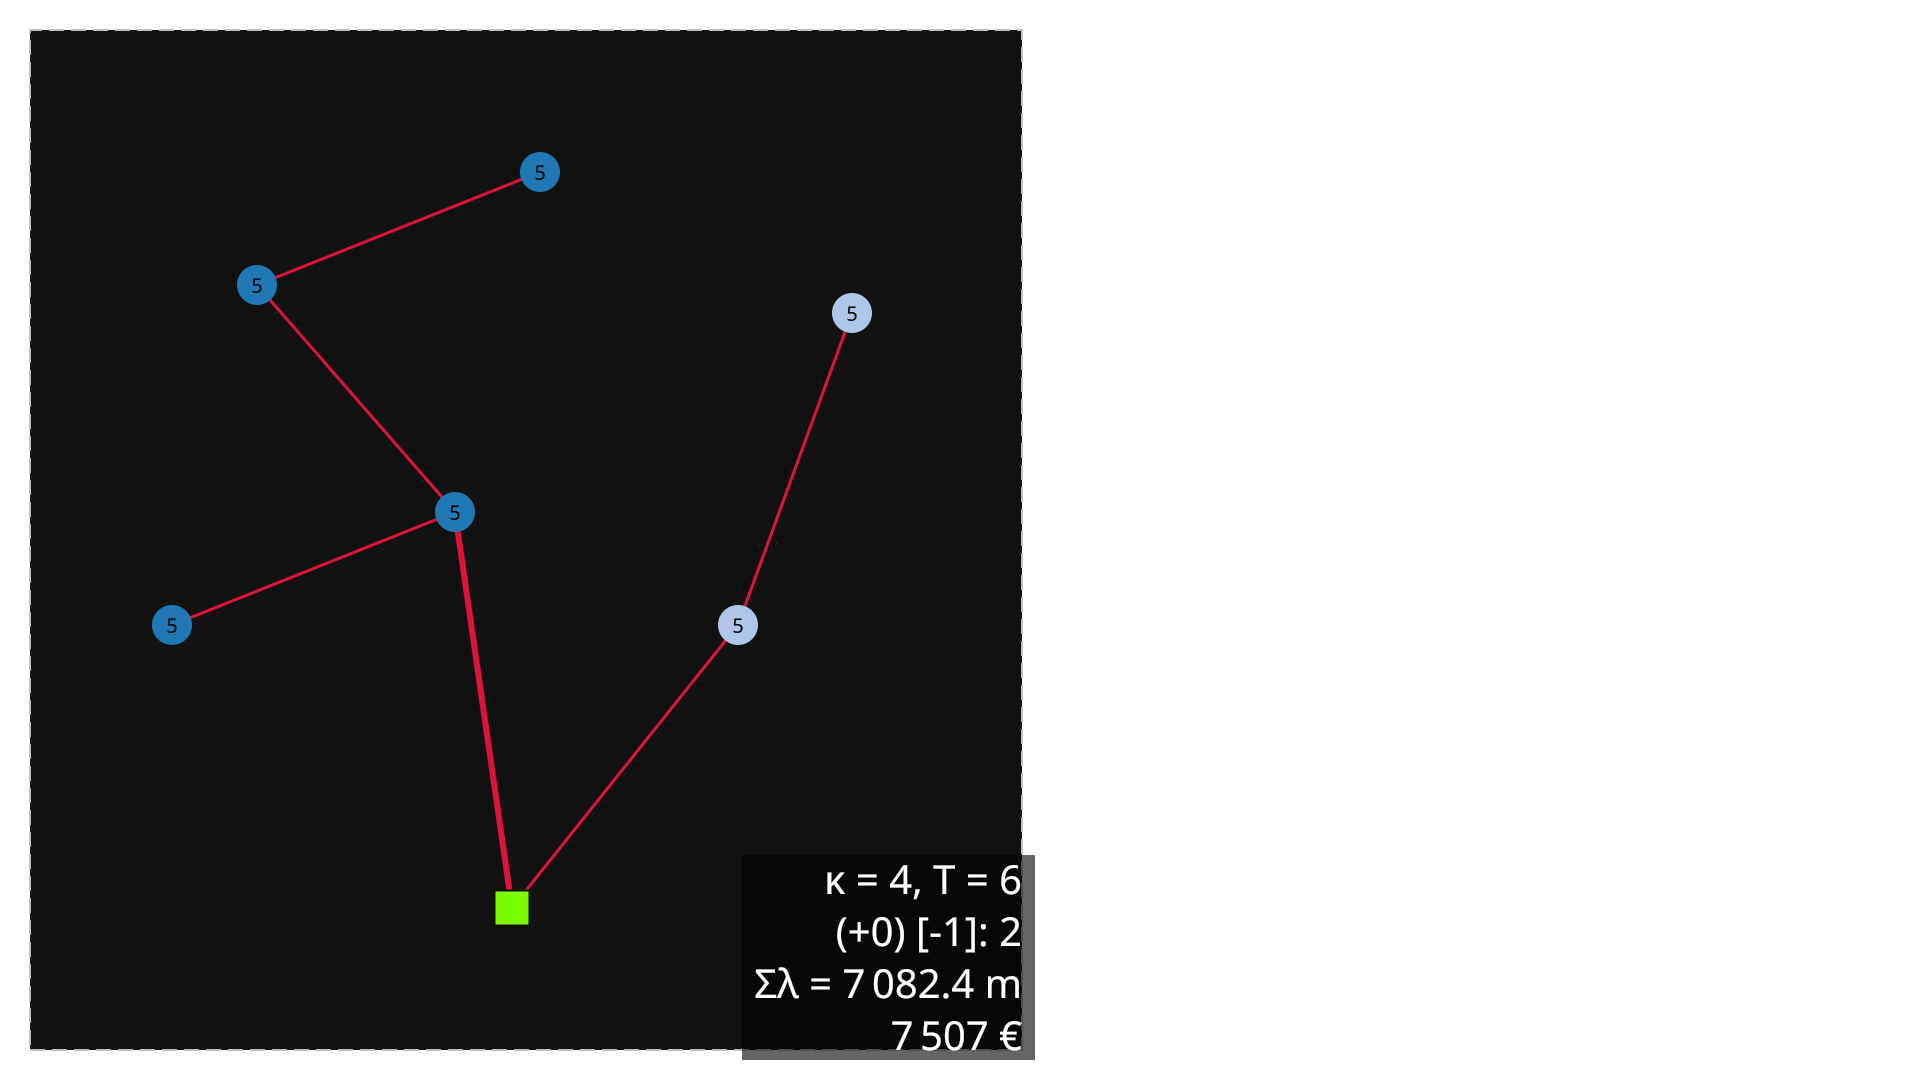

In [16]:
svgplot(uniform.G, node_tag='power')

In [17]:
unspecified = WindFarmNetwork(**site, cables=3)

In [18]:
assert unspecified.turbine_powers is None
assert unspecified.power_unit is None
{
    'unspecified_power': unspecified.turbine_powers,
    'power_unit': unspecified.power_unit,
}

{'unspecified_power': None, 'power_unit': None}

### Integer inflow without a physical unit

Explicit positive integer `turbine_powers` can describe weighted demands without assigning a physical unit. Cable capacities then use those same integer units. Float powers and capacities are refused in this mode, including whole-valued floats.

In [19]:
weighted = WindFarmNetwork(
    **site,
    name='Integer demands: 1 and 2',
    turbine_powers=[1, 2] * 3,
    cables=4,
    router=make_router(),
)
weighted.optimize()

TerseLinks(scope='topology', topology='branched', T=6, R=1, links=6)

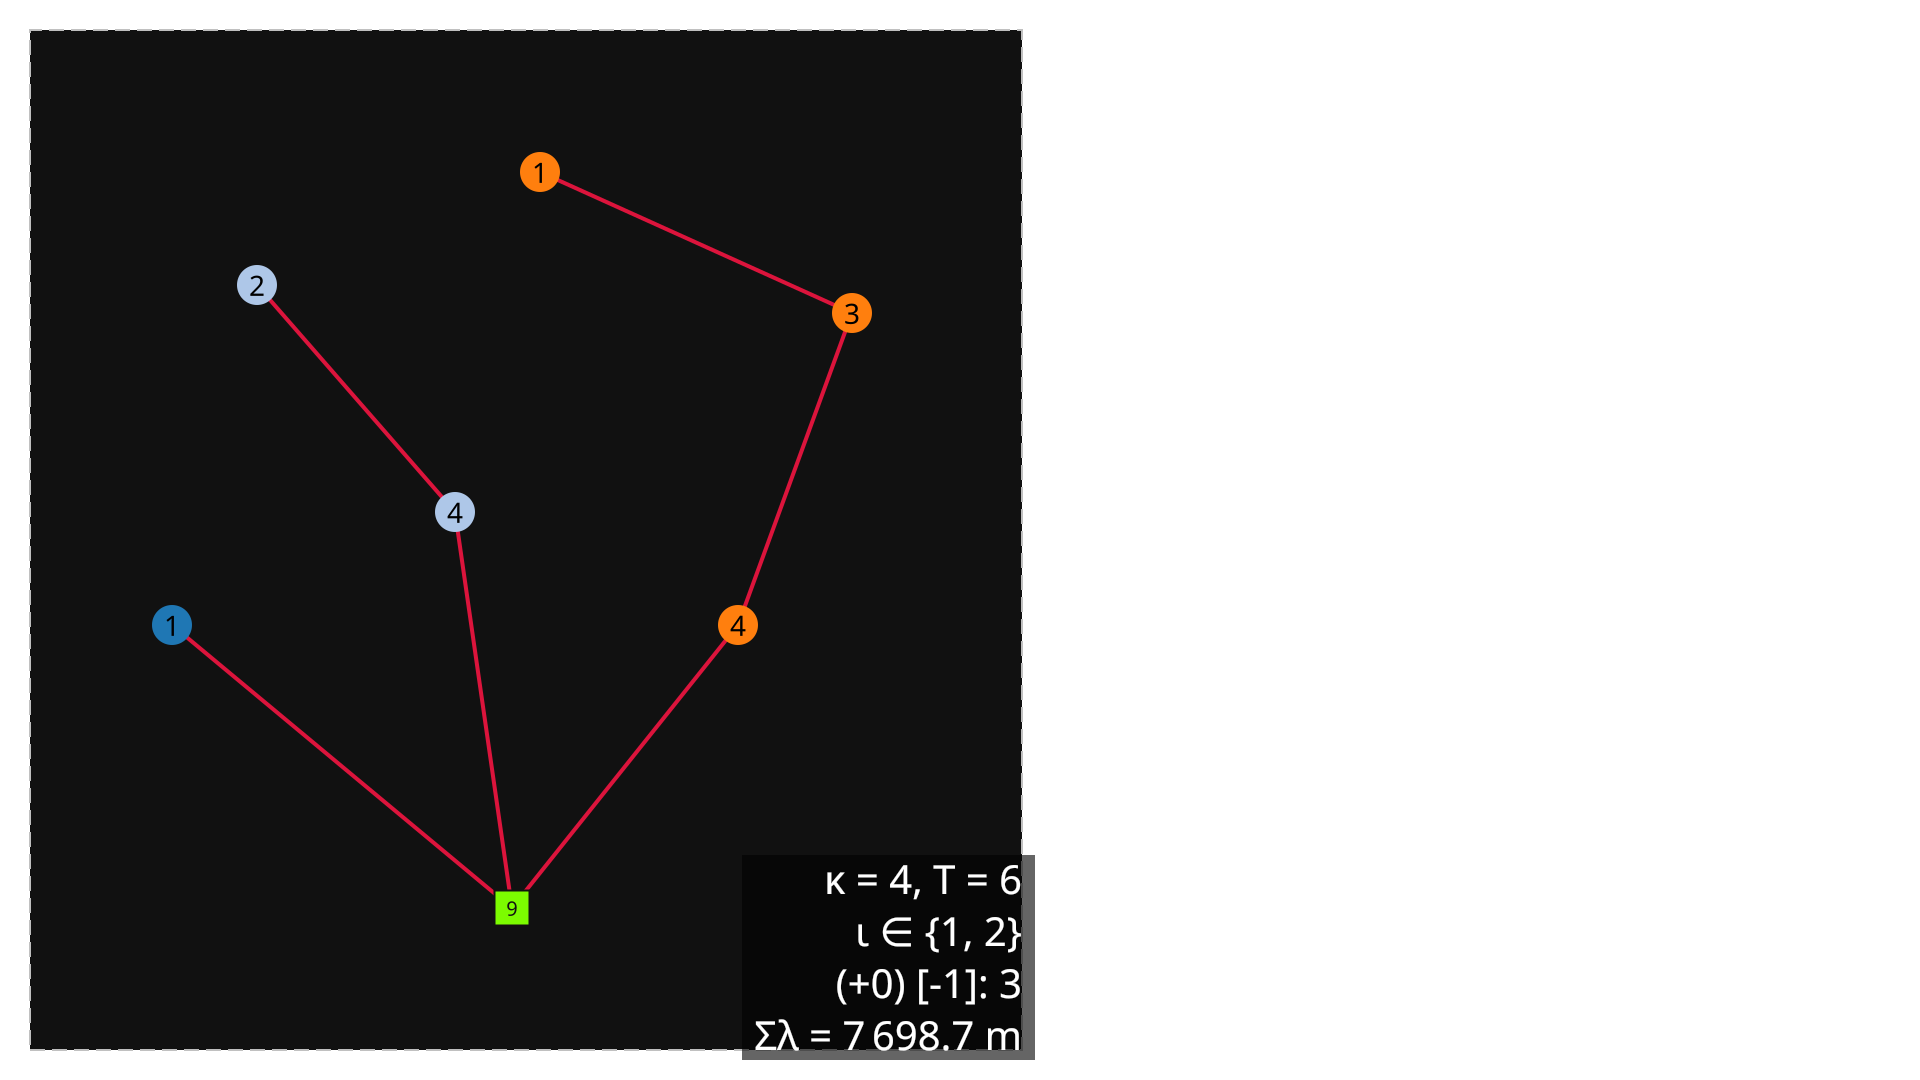

In [20]:
assert weighted.power_unit is None
assert weighted.turbine_powers == [1, 2] * 3
assert weighted.G.nodes[-1]['load'] == 9
svgplot(weighted.G, node_tag='load')

### Read and export loads

`plot(node_tag='load')` labels cumulative integer inflow. `plot(node_tag='power')` always labels each turbine's declared nominal rating, falling back to `inflow * power_per_inflow` when no power is declared. Multiplying cumulative load by `power_per_inflow` gives a nominal approximation that can differ from the sum of declared MW when tolerance is nonzero.

`get_network()` reports the sum of **declared** downstream power in its floating-point `load` field. Sum only the substation links to recover total generation; summing every cable load would count upstream turbines repeatedly. The graph's routing `load` remains an integer.

`mixed.plot(node_tag='load_nominal')` labels cumulative nominal loads on demand. Exact quantization scales the integer loads for display; inexact quantization traverses the network to sum the declared ratings, refreshing the `load_nominal` attributes. The `power_quantization_inexact` graph flag comes from quantization and selects the path. Ordinary `calcload()` calculates only integer loads.

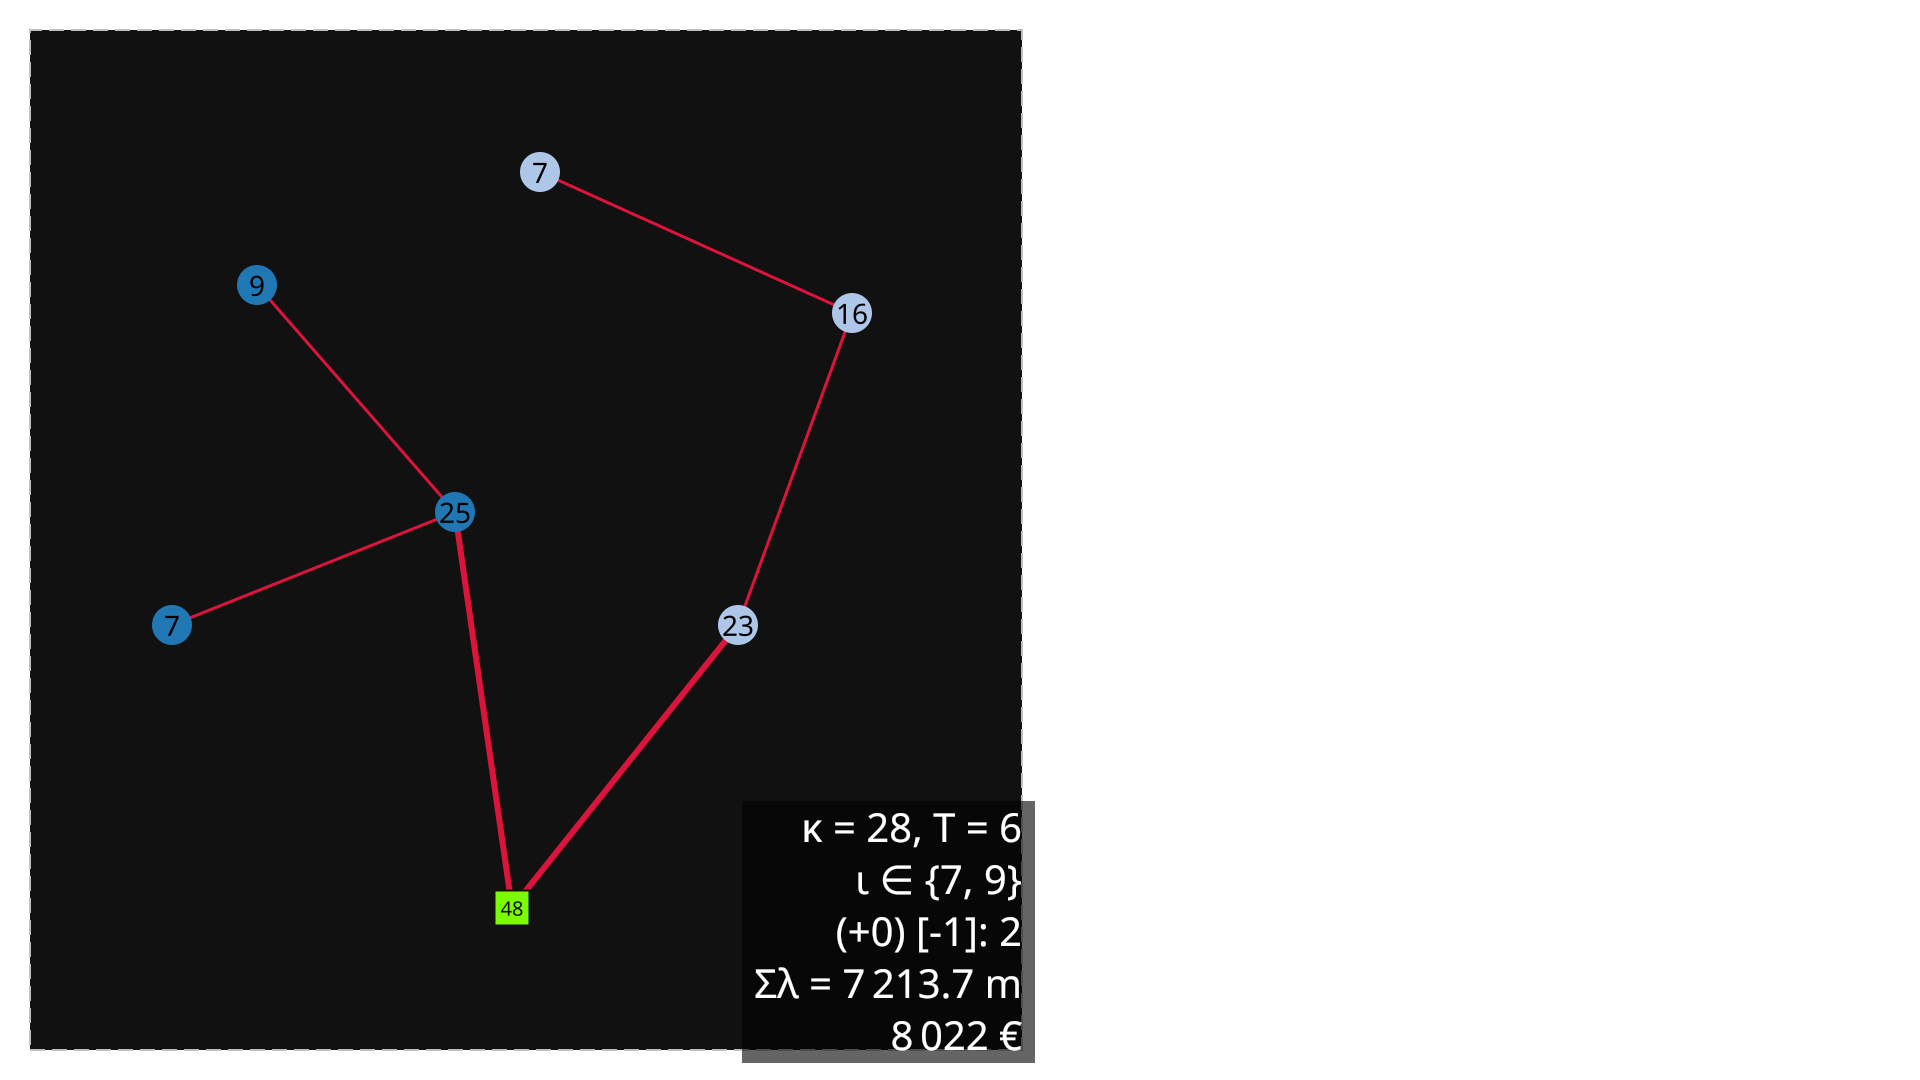

In [21]:
mixed.plot(node_tag='load')

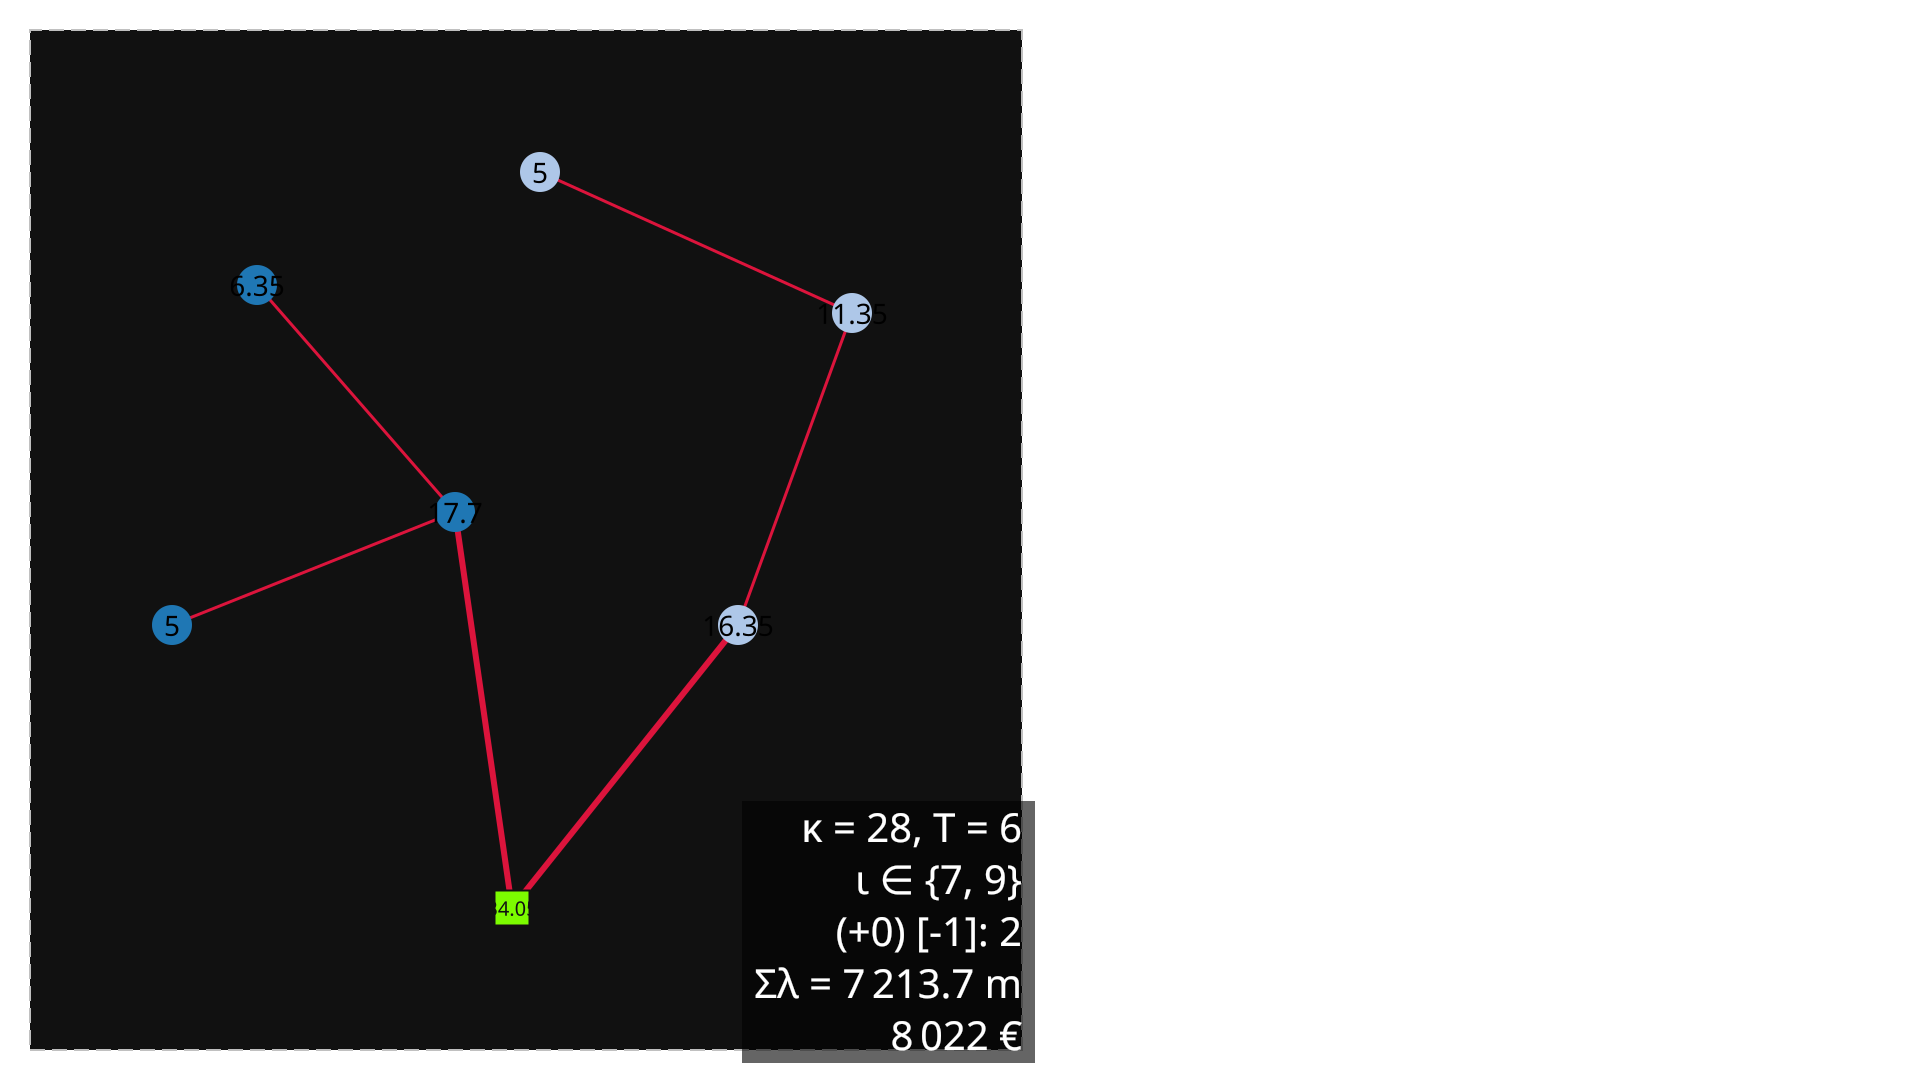

In [22]:
mixed.plot(node_tag='load_nominal')

In [23]:
exported = mixed.get_network()
feeders = exported[(exported['src'] < 0) | (exported['tgt'] < 0)]
tabulate(feeders, headers=list(feeders.dtype.names), tablefmt='html')

src,tgt,length,load,cable
1,-1,1414.21,17.7,1
2,-1,1280.62,16.35,1


In [24]:
assert np.isclose(feeders['load'].sum(), sum(powers_MW))
{
    'exported_generation_MW': feeders['load'].sum(),
    'declared_generation_MW': float(sum(mixed.turbine_powers)),
}

{'exported_generation_MW': np.float64(34.05), 'declared_generation_MW': 34.05}

### Reconstruct from terse links

A terse encoding keeps the links, but not turbine ratings or inflows. Supply the same location, cables, unit and router tolerance when reconstructing it. `update_from_terse_links()` quantizes the location as a solve would, so both integer and nominal loads are recovered.

In [25]:
restored = WindFarmNetwork(
    L=mixed.L,
    cables=mixed.cables,
    power_unit=mixed.power_unit,
    router=make_router(),
)
restored.update_from_terse_links(mixed.terse_links())

In [26]:
assert restored.G.graph['power_per_inflow'] == mixed.G.graph['power_per_inflow']
for u, v, data in mixed.G.edges(data=True):
    assert restored.G[u][v]['load'] == data['load']
    assert restored.G[u][v]['load_nominal'] == data['load_nominal']
{'restored_generation_MW': restored.G.nodes[-1]['load_nominal']}

{'restored_generation_MW': Fraction(681, 20)}

### Reassign cable types

Changing `cables` keeps a solution whose nominal loads still fit and reassigns its cable types. It does not requantize that solution. If the largest capacity falls below an existing load, the solution is invalidated and the next optimization solves with the new budget. The location and mesh keep their nominal declaration.

Use the restored network for this experiment. First retain the 20 MW limit while reducing the smaller cable to 10 MW; then reduce the largest capacity to 10 MW. This site needs a different topology to carry all its power under that limit.

In [27]:
previous_G = restored.G
previous_unit = previous_G.graph['power_per_inflow']
previous_A = restored.A
assert max(data['load_nominal'] for _, _, data in previous_G.edges(data=True)) > 10

restored.cables = [(10, 1.0), (20, 1.3)]
assert restored.G is previous_G
assert restored.G.graph['power_per_inflow'] == previous_unit
assert restored.A is previous_A
{
    'reassigned_cable_types': sorted(
        {d['cable'] for _, _, d in restored.G.edges(data=True)}
    ),
}

{'reassigned_cable_types': [0, 1]}

In [28]:
restored.cables = [(10, 1.0)]
restored.optimize()
assert restored.G is not previous_G
assert restored.A is previous_A
assert max(restored.get_network()['load']) <= 10
assert all('inflow' not in restored.A.nodes[t] for t in range(6))

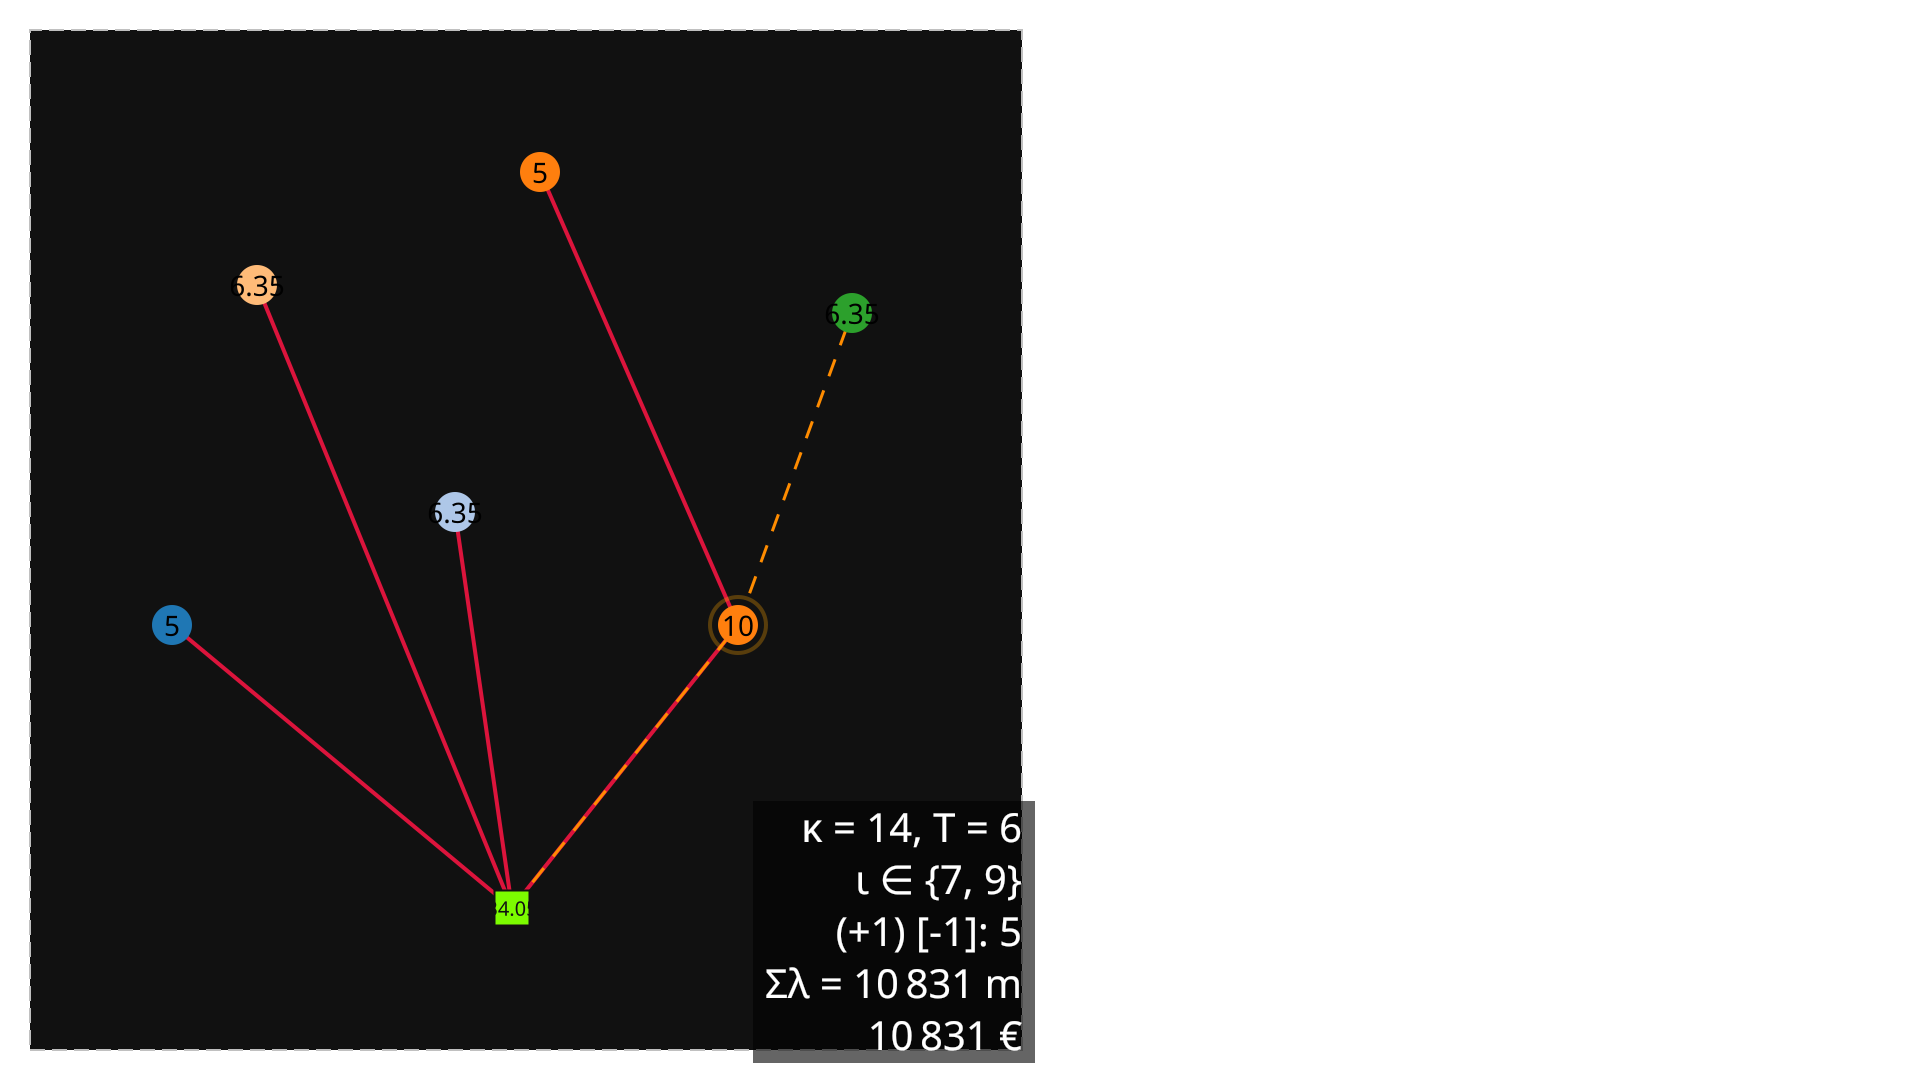

In [29]:
svgplot(restored.G, node_tag='load_nominal')

### Locations with power declarations

When using `WindFarmNetwork(L=L, power_unit='MW', ...)`, the location supplies the powers if `turbine_powers` is omitted. The unit must match the location's declaration; an explicit `turbine_powers` overrides its ratings. `WindFarmNetwork.from_own_yaml(..., power_unit='MW')` also reads declared ratings.

With the default `power_unit=None`, the network drops the location's declaration from its own copy and uses unitary inflow unless integer `turbine_powers` are supplied. Ignoring unequal ratings logs a warning. This choice changes the interpretation of capacity, rather than converting MW to turbine counts.

An OWN YAML `TURBINE` mapping supplies a common `power_MW`; a list assigns mixed models by consecutive `qty` blocks or by turbine-label `prefix`. The bundled Borssele and Walney Extension locations contain mixed ratings. OSM imports read `generator:output:electricity` when every turbine declares a positive output in a common unit. See [input formats](../reference/input_formats.md) for complete file examples.

In [30]:
locations = load_repository()
L_imported = locations.borssele
imported = WindFarmNetwork(
    L=L_imported,
    power_unit='MW',
    cables=[40, 60],
    router=make_router(),
)

In [31]:
assert set(imported.turbine_powers) == {Fraction(8), Fraction('9.5')}
{
    'unit': imported.power_unit,
    'distinct_ratings_MW': sorted(set(imported.turbine_powers)),
    'total_declared_MW': sum(imported.turbine_powers),
}

{'unit': 'MW',
 'distinct_ratings_MW': [Fraction(8, 1), Fraction(19, 2)],
 'total_declared_MW': Fraction(3005, 2)}

In [32]:
counted = WindFarmNetwork(L=L_imported, cables=6)

L declares unequal turbine power in MW, which is ignored because power_unit is None: every turbine injects unitary inflow. Pass power_unit='MW' to route by the declared power.


In [33]:
assert counted.turbine_powers is None
assert counted.power_unit is None
assert 'powers_set' not in counted.L.graph
assert 'powers_set' in L_imported.graph
{'cables_counting_turbines': counted.cables}

{'cables_counting_turbines': [(6, 0.0)]}

### Choose a compatible router

| Router or option | Nonunit-inflow support |
| --- | --- |
| `MILPRouter` | Radial or branched; feeder limits `'unlimited'`, `'exactly'`, or `'specified'`. |
| `HGSRouter` | Unbalanced, single-substation radial networks. |
| `EWRouter` (the default router) | Rejects nonunit inflow; choose a supported router explicitly. |
| Ringed models; MILP `'minimum'` / `'min_plus*'` feeder limits | Unsupported for nonunit inflow. Total power alone does not establish a feasible partition of indivisible turbines. |

These restrictions concern the quantized inflows. Unequal ratings can sometimes quantize to unitary inflow under a loose tolerance, which every router supports.

Power values must be positive and finite, with one entry per turbine; the router's `power_rtol` must be in `[0, 1)`. Excessively fine quantization can exceed the supported integer-inflow range and raise `ValueError`. A turbine must fit the largest cable.

Routeset database storage rejects nonunit inflow **or** a `powers_set` declaration, even if unequal ratings quantize to unitary inflow. Equal-power routesets can be stored with their power attributes. `get_network()` is a reporting export; retain the location and power inputs to reproduce a design.